In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA


In [3]:
# Upload Zoo.csv manually or from local/Google Drive
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Zoo.csv")
df.head()


Saving Zoo.csv to Zoo (1).csv


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [4]:
# Drop the 'animal name' column
df_clean = df.drop(columns=["animal name"])

# Features and Target
X = df_clean.drop(columns=["type"])
y = df_clean["type"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)


KNeighborsClassifier(metric='euclidean')

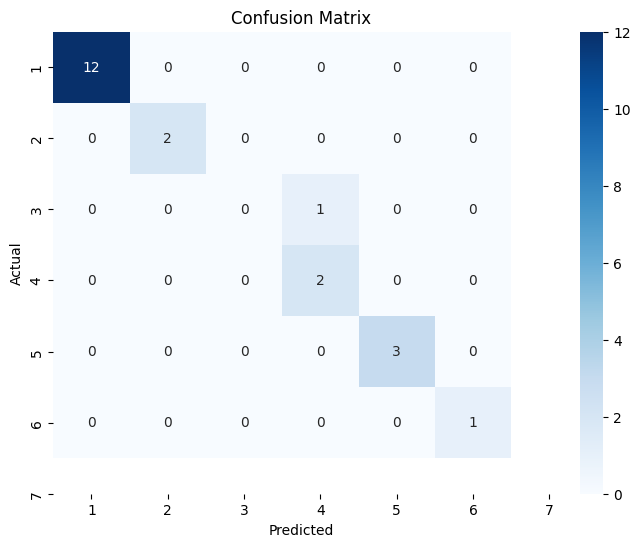

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
y_pred = knn.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(1,8), yticklabels=range(1,8))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))


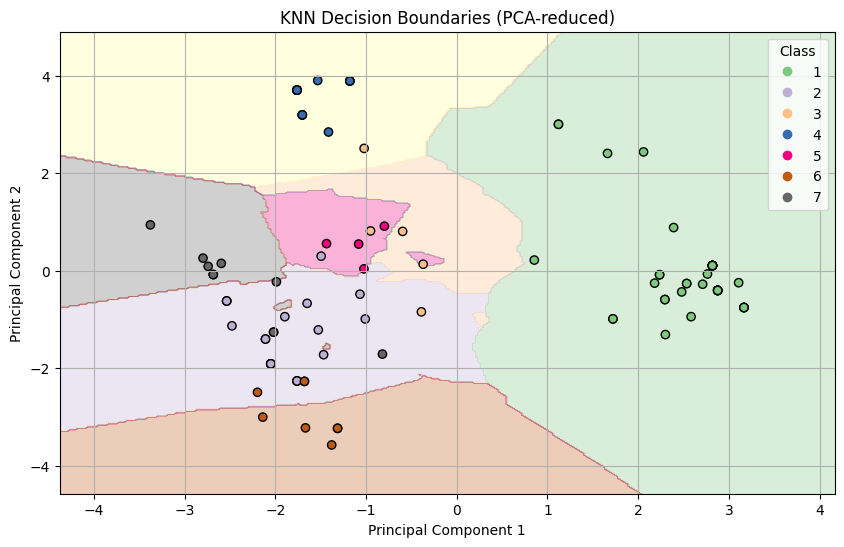

In [8]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Fit KNN again on reduced data for visualization
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca, y)

# Create meshgrid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Accent')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Accent', edgecolor='k')
plt.title("KNN Decision Boundaries (PCA-reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Class")
plt.grid(True)
plt.show()


1. What are the key hyperparameters in KNN?
The main hyperparameters in the K-Nearest Neighbors (KNN) algorithm are:

n_neighbors: This specifies the number of nearest neighbors (K) to consider when making a prediction. A common choice is an odd number like 3 or 5 to avoid ties in voting.

weights: This determines how the neighbors contribute to the prediction. If set to 'uniform', all neighbors have equal influence. If set to 'distance', closer neighbors have more influence on the prediction than those further away.

metric: This defines the method used to measure distance between data points. Common choices include Euclidean, Manhattan, and Minkowski distances.

p: This is the power parameter for the Minkowski distance. When p=1, it behaves like Manhattan distance; when p=2, it becomes Euclidean distance.

algorithm: This controls the method used to compute the nearest neighbors. Options include 'auto', 'ball_tree', 'kd_tree', and 'brute'. While it doesn't affect accuracy, it can significantly affect computation time on large datasets.

2. What distance metrics can be used in KNN?
There are several distance metrics you can use in KNN, depending on the type and nature of your data:

Euclidean distance is the most commonly used. It measures the straight-line distance between two points and is best suited for continuous numerical features.

Manhattan distance measures the distance by summing the absolute differences of each coordinate. It is useful when data has high dimensions or when the features are not related in a continuous space.

Minkowski distance is a generalized form of both Euclidean and Manhattan distances. You can control how it behaves using the p parameter.

Hamming distance is used for categorical or binary variables. It counts the number of positions at which the corresponding features are different.

Cosine similarity is used mainly in text classification or other high-dimensional spaces. It measures the cosine of the angle between two vectors rather than the actual distance.

Chebyshev distance takes the maximum absolute difference between coordinates of a pair of points.